The Normal Equation

In [6]:
#Test the Normal Equation
import numpy as np

In [7]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [8]:
import matplotlib.pyplot as plt

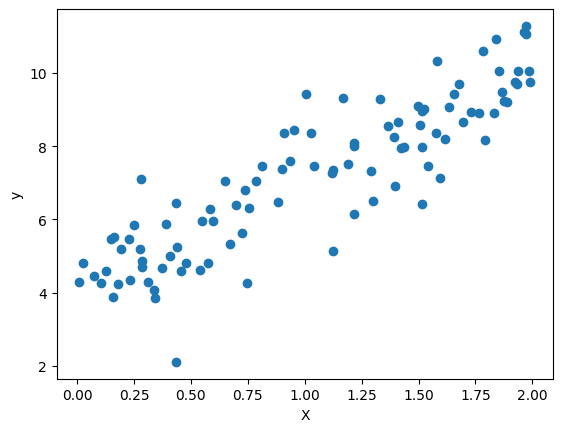

In [9]:
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [10]:
X_b = np.c_[np.ones((100, 1)), X]
X_b

array([[1.        , 1.49876657],
       [1.        , 0.43978968],
       [1.        , 1.87350054],
       [1.        , 0.88344165],
       [1.        , 0.07499328],
       [1.        , 0.9532733 ],
       [1.        , 1.580033  ],
       [1.        , 1.1911502 ],
       [1.        , 1.00582516],
       [1.        , 0.2504883 ],
       [1.        , 0.28642122],
       [1.        , 1.29063066],
       [1.        , 0.75488516],
       [1.        , 0.391092  ],
       [1.        , 1.50713688],
       [1.        , 0.27492029],
       [1.        , 1.57861402],
       [1.        , 0.47856068],
       [1.        , 1.93510614],
       [1.        , 1.21551492],
       [1.        , 0.74586069],
       [1.        , 1.61500982],
       [1.        , 0.10346891],
       [1.        , 1.65520989],
       [1.        , 0.90155841],
       [1.        , 0.23443543],
       [1.        , 0.5406463 ],
       [1.        , 0.28180184],
       [1.        , 0.59615354],
       [1.        , 1.6957404 ],
       [1.

In [11]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[4.09281964],
       [2.97939089]])

In [12]:
X_new = np.array([[0], [2]])
X_new

array([[0],
       [2]])

In [13]:
X_new_b = np.c_[np.ones((2, 1)), X_new]
X_new_b

array([[1., 0.],
       [1., 2.]])

In [14]:
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 4.09281964],
       [10.05160142]])

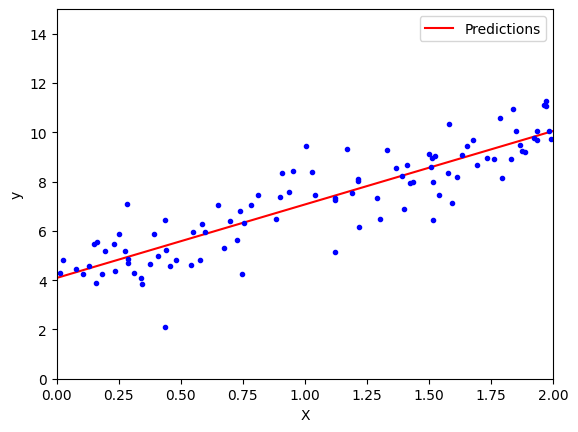

In [15]:
plt.plot(X_new, y_predict, 'r-', label='Predictions')
plt.plot(X, y, 'b.')
plt.axis([0, 2, 0, 15])
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [16]:
# Perform Linear Regression
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [17]:
lin_reg.fit(X,y)

LinearRegression()

In [18]:
lin_reg.intercept_, lin_reg.coef_

(array([4.09281964]), array([[2.97939089]]))

In [19]:
lin_reg.predict(X_new)

array([[ 4.09281964],
       [10.05160142]])

In [20]:
# Compare with the function Linear Regression is based on
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond = 1e-6)
theta_best_svd

array([[4.09281964],
       [2.97939089]])

In [21]:
# Compute the pseudoinverse directly
np.linalg.pinv(X_b).dot(y)

array([[4.09281964],
       [2.97939089]])

In [22]:
# Compute the Batch Gradient Descent
eta = 0.1 #learning rate
n_iterations = 1000
m = 100

In [23]:
theta = np.random.randn(2,1) #random initialization

In [24]:
for iteration in range (n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

In [25]:
theta

array([[4.09281964],
       [2.97939089]])

In [26]:
#Compute Stochastic Gradient Descent

n_epochs = 50 #rounds of iteration
t0, t1 = 5, 50 # learning schedule hyperparameters

In [27]:
def learning_schedule (t):
    return t0/(t + t1)

In [28]:
import numpy as np
theta = np.random.randn(2,1) #random initialization

In [29]:
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + 1)
        theta = theta - eta * gradients

In [30]:
theta

array([[4.1247191 ],
       [3.00669879]])

In [31]:
#Linear Regression using Stochastic GD
from sklearn.linear_model import SGDRegressor

In [33]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

SGDRegressor(eta0=0.1, penalty=None)

In [35]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.03885687]), array([2.95263395]))